<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/#create=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

In [ ]:
nombre = input("📝 Ingresa tu nombre completo: ")
correo = input("📧 Ingresa tu correo electrónico: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de tu cédula: ")

📝 Ingresa tu nombre completo: Santiago Correa Marulanda
📧 Ingresa tu correo electrónico: santiago.correa7@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de tu cédula: 486496


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis

In [2]:
base = 486496
np.random.seed(base)
media_teorica = (base%10)+2
desv_std = 2
tam = 60
ingresos = np.random.normal(media_teorica, desv_std, tam).round(1)
mediana = np.median(ingresos)
moda = stats.mode(ingresos,keepdims=True)[0][0]

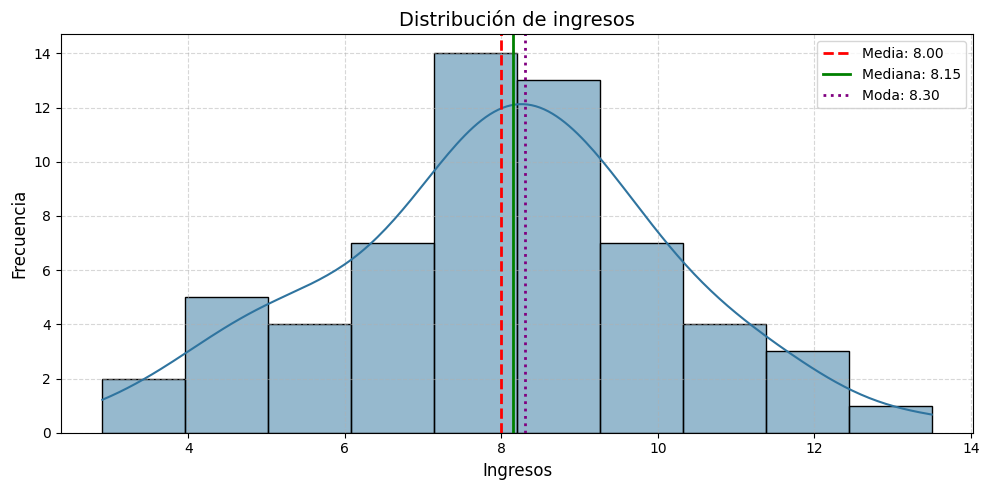

In [3]:
plt.close()
plt.figure(figsize=(10, 5))
sns.histplot(ingresos, bins=10, kde=True, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media_teorica, color='red', linestyle='--', linewidth=2, label=f'Media: {media_teorica:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Estética
plt.title("Distribución de ingresos", fontsize=14)
plt.xlabel("Ingresos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Interpretación:
**Media:** Hay en promedio 8 unidades (podriamos hablar de unidades de mil) de ingresos

**Mediana:** La mitad de los ingresos están por encima de este (8.15) y la otra mitad está por debajo

**Moda:** El valor de ingresos que más se repite es 8.30

### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos

In [4]:
rango = np.max(ingresos)-np.min(ingresos)
varianza = np.var(ingresos,ddof=1)
desv_std = np.std(ingresos,ddof=1)
cv = varianza/media_teorica
print(f"Rango = {rango}\nVarianza = {varianza}\nDesviacion standar = {desv_std}\nCoeficiente de variación = {cv}")

Rango = 10.6
Varianza = 4.57419209039548
Desviacion standar = 2.1387360964820976
Coeficiente de variación = 0.571774011299435


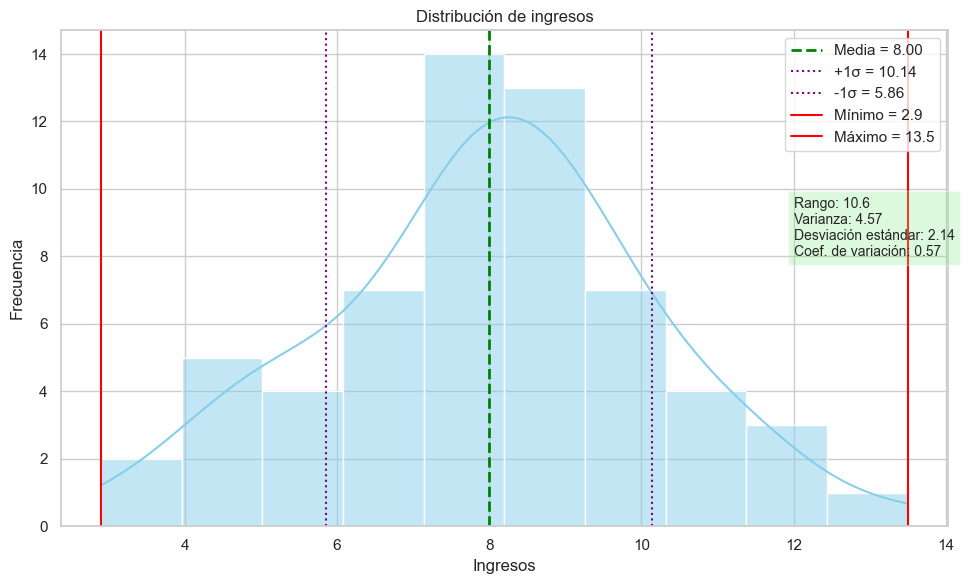

In [5]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(ingresos, bins=10, kde=True, color='skyblue')

# Líneas verticales
plt.axvline(media_teorica, color='green', linestyle='--', linewidth=2, label=f'Media = {media_teorica:.2f}')
plt.axvline(media_teorica + desv_std, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media_teorica + desv_std:.2f}')
plt.axvline(media_teorica - desv_std, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media_teorica - desv_std:.2f}')
plt.axvline(np.min(ingresos), color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {np.min(ingresos)}')
plt.axvline(np.max(ingresos), color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {np.max(ingresos)}')

# Título y etiquetas
plt.title("Distribución de ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desv_std:.2f}\n"
    f"Coef. de variación: {cv:.2f}"
)
plt.text(12, 8, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

# Interpretación
**Rango:** Se podria decir que se ve una gran diferencia entre el mínimo y máximo ingreso, ya que es solo un poco menor al valor máximo

**Varianza:** En cuanto a esta, se observa que los diferentes ingresos están considerablemente alejados de la media, no demasiado, pero algo notable

**Desviacion estandar:** Se observa que la mayoría de los ingresos están a una distancia aproximada de 2.14 unidades de la media, lo que muestra una dispersión moderada

**Coeficienta de variacion:** Este es del 57%, es decir, es considerablemente alto, nos dice que aunque los ingresos son mayormente cercanos a la media, hay una cantidad significativa de variabilidad entre las observaciones

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal


In [6]:
asimetria = skew(ingresos)
curtosis = kurtosis(ingresos)

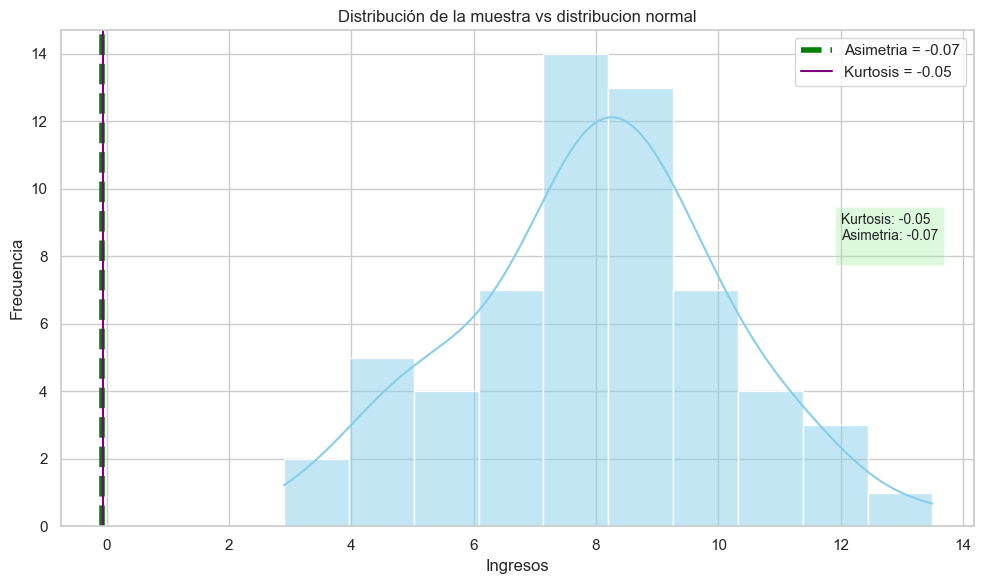

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(ingresos, bins=10, kde=True, color='skyblue')

# Líneas verticales
plt.axvline(asimetria, color='green', linestyle='--', linewidth=4, label=f'Asimetria = {asimetria:.2f}')
plt.axvline(curtosis, color='purple', linestyle='-', linewidth=1.5, label=f'Kurtosis = {curtosis:.2f}')

# Título y etiquetas
plt.title("Distribución de la muestra vs distribucion normal")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Kurtosis: {curtosis:.2f}\n"
    f"Asimetria: {asimetria:.2f}\n"
)
plt.text(12, 8, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

# Interpretación

**Asimetria:** Podemos ver que su valor, aunque negativo, es muy cercano a cero, por lo que los ingresos siguen una distribucion simetrica, pero se observa que puede haber una pequeña tendencia a que los ingresos sean mayores a la media

**Kurtosis:** Graficamente se ve que hay picos pronunciados, pero esto se puede deber a los bins, ya que segun el valor de kurtosis se podria decir que los ingresos estan distribuidos de una manera mas uniforme

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos


C:\Users\HP\AppData\Local\Temp\ipykernel_3372\2367909093.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(ingresos, kde=True, palette="pastel", bins=10)


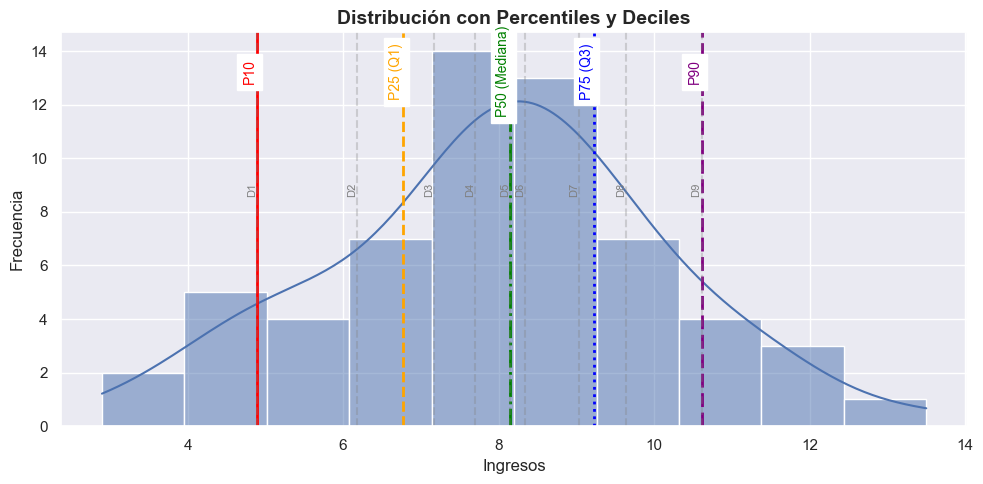

In [8]:
# Estilo visual
sns.set_theme(style="darkgrid")

# Cálculo de percentiles clave
percentiles = {
    'P10': {'valor': np.percentile(ingresos, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(ingresos, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(ingresos, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(ingresos, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(ingresos, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(ingresos, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(10,5))
sns.histplot(ingresos, kde=True, palette="pastel", bins=10)

# Líneas verticales para percentiles destacados
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'],
                linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.9, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             backgroundcolor='white')

# Líneas más sutiles para deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.6, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')


# Títulos y estilo
plt.title("Distribución con Percentiles y Deciles", fontsize=14, fontweight='bold')
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Interpretación
**Percentil 10:** Nos dice que el 10% de los datos están por debajo de este, que gráficamente este valor es aproximadamente 5, es decir, el 10% de los ingresos son menores a 5

**Percentil 25 o Cuantil 1:** El 25% de los ingresos son menores a un poco menos de 7

**Percentil 50 o Cuantil 2:** El 50% de los ingresos son menores a 8

**Percentil 7 o Cuantil 3:** El 75% de los ingresos son menores a 9

**Percentil 90** El 90% de los ingresos son menores a un poco menos de 11



## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.

In [9]:
base = 486496
np.random.seed(base)
media_1 = (base % 10) +22
media_2 = (base % 10) +7
desviacion_1 = 3
desviacion_2 = 2
tamaño = 60

pm10 = np.random.normal(media_1, desviacion_1, tamaño)
pm2_5 = np.random.normal(media_2, desviacion_2, tamaño)

In [10]:
from scipy.stats import pearsonr

p,_ = pearsonr(pm10, pm2_5)


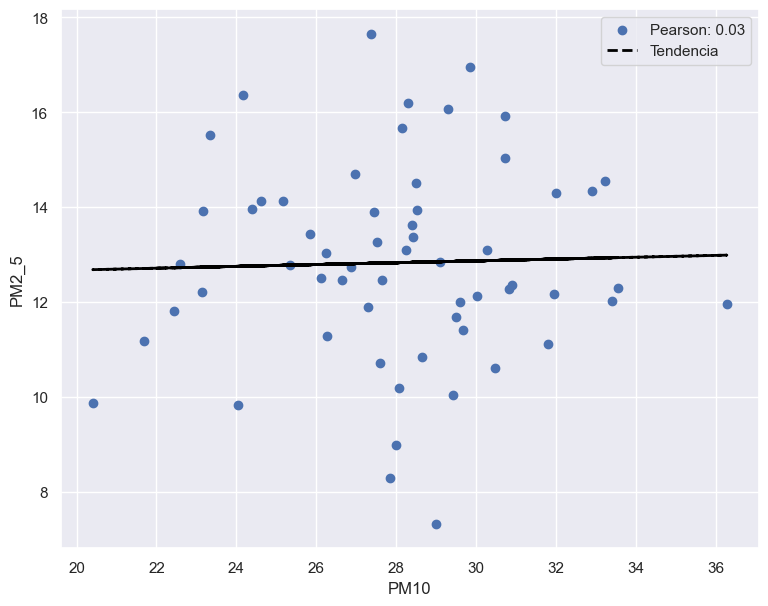

In [11]:
plt.figure(figsize=(9,7))
plt.scatter(pm10,pm2_5, label=f"Pearson: {p:.2f}")
plt.xlabel("PM10")
plt.ylabel("PM2_5")
m, b = np.polyfit(pm10, pm2_5, 1)  # ajuste lineal (pendiente y corte)
plt.plot(pm10, m*pm10 + b, color="black", linewidth=2, linestyle="--", label="Tendencia")
plt.legend()
plt.show()

# Interpretación

**Aunque hay una ligera tendencia de aumento de PM2.5 conforme aumenta PM10, la correlación extremadamente baja indica que no hay una relación significativa entre estas dos variables en el conjunto de datos**

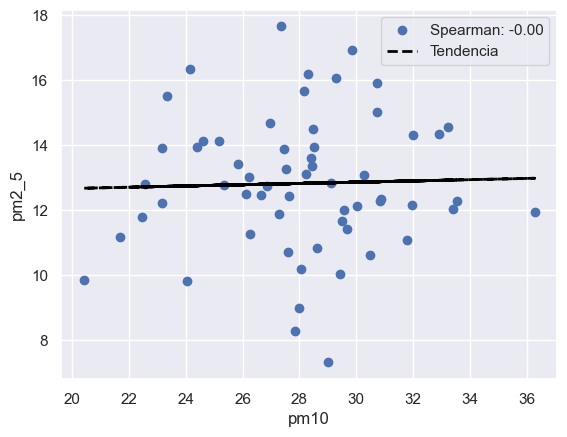

In [ ]:
from scipy.stats import spearmanr

rho,_ = spearmanr(pm10,pm2_5)
plt.scatter(pm10,pm2_5, label=f"Spearman: {rho:.2f}")
plt.xlabel("pm10")
plt.ylabel("pm2_5")
m, b = np.polyfit(pm10, pm2_5, 1)  # ajuste lineal (pendiente y corte)
plt.plot(pm10, m*pm10 + b, color="black", linewidth=2, linestyle="--", label="Tendencia")
plt.legend()
plt.show()

# Interpretación

**El gráfico muestra que no hay una relación importante entre las concentraciones de PM10 y PM2.5, tanto en términos de correlación de Pearson como de Spearman**

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

Tabla de contingencia:
Acceso a internet  No  Sí
Nivel educativo          
Básico              9  19
Medio               2  20
Superior            1   9

Resultados Chi-cuadrado:
Chi2 = 4.84, p-valor = 0.0888, grados de libertad = 2
Frecuencias esperadas:
 Acceso a internet   No    Sí
Nivel educativo             
Básico             5.6  22.4
Medio              4.4  17.6
Superior           2.0   8.0 



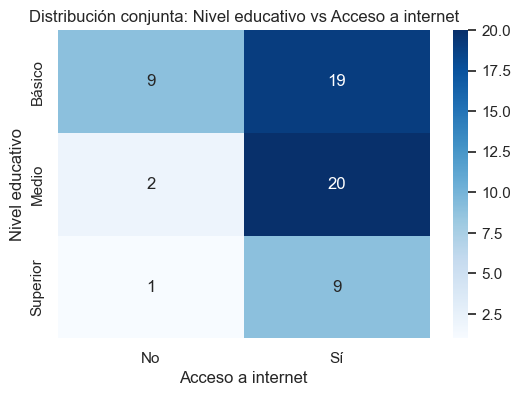

In [17]:
import pandas as pd
from scipy.stats import chi2_contingency
np.random.seed(225458)

# Tamaño de muestra
tamaño_muestra = 60

# Variables categóricas
niveles_educativos = ["Básico", "Medio", "Superior"]
internet = ["Sí", "No"]

nivel_educativo = np.random.choice(niveles_educativos, size=tamaño_muestra, p=[0.4, 0.4, 0.2])   
acceso_internet = np.random.choice(internet, size=tamaño_muestra, p=[0.67, 0.33]) 

df = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

# Tabla de contingencia
tabla = pd.crosstab(df["Nivel educativo"], df["Acceso a internet"])
print("Tabla de contingencia:")
print(tabla)

chi2, p, dof, esperados = chi2_contingency(tabla)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.2f}, p-valor = {p:.4f}, grados de libertad = {dof}")
print("Frecuencias esperadas:\n",pd.DataFrame(esperados, index=tabla.index, columns=tabla.columns), "\n")


# Visualización (mapa de calor)
plt.figure(figsize=(6,4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Distribución conjunta: Nivel educativo vs Acceso a internet")
plt.show()



# Interpretación

**El valor chi-cuadrado es relativamente alto, lo que indica que hay una diferencia bastante notable entre los valores observados y los esperados**

**En cuanto al valor p, este valor es mayor que 0.05, lo que sugiere que no hay suficiente evidencia, estadisticamente hablando, para rechazar la hipótesis nula de que el nivel educativo y el acceso a internet son independientes**

**El grafico de calor observa claramente que, a medida que aumenta el nivel educativo, tambien aumenta el número de personas con acceso a internet, sin embargo, el número de personas sin acceso a internet sigue siendo bajo especialmente en los niveles superiores**